In [1]:
from funasr import AutoModel

model = AutoModel(model="iic/emotion2vec_plus_large",
hub="hf")

funasr version: 1.3.1.
Check update of funasr, and it would cost few times. You may disable it by set `disable_update=True` in AutoModel
You are using the latest version of funasr-1.3.1


Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.weight, /workspace/.cache/huggingface/hub/models--emotion2vec--emotion2vec_plus_large/snapshots/6c303ba987b86b93193de93e34bb2b077a6bedc4/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.bias, /workspace/.cache/huggingface/hub/models--emotion2vec--emotion2vec_plus_large/snapshots/6c303ba987b86b93193de93e34bb2b077a6bedc4/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.weight, /workspace/.cache/huggingface/hub/models--emotion2vec--emotion2vec_plus_large/snapshots/6c303ba987b86b93193de93e34bb2b077a6bedc4/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.bias, /workspace/.cache/huggingface/hub/models--emotion2vec--emotion2vec_plus_large/snapshots/6c303ba987b86b93193de93e34bb2b077a6bedc4/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.2.0.weight, /workspace/.cache/huggingface/hub/models--emotion2vec--emotion

In [2]:
import librosa
sr = 16000
audio_path = "/workspace/tmp_data/3d48c229-3505-4a40-b4d2-1e704aa0b8cc.mp3"
audio_path = "/workspace/tmp_data/jamespiper-2026-2-9__14-44-54.mp3"
audio_path = "/workspace/tmp_data/robbiestaniforth-2026-2-9__14-44-54.mp3"

import os
os.path.exists(audio_path)

True

In [3]:

y,_ = librosa.load(audio_path, sr=sr)

In [18]:
audio=y

In [4]:
y.dtype

dtype('float32')

In [6]:
import numpy as np

window_samples = int(3 * sr)   # 32000
hop_samples = int(0.25 * sr)      # 16000
batch_size = 25

# Zero-copy strided view — shape: (frame_length, n_frames)
frames = librosa.util.frame(y, frame_length=window_samples, hop_length=hop_samples)
frames = frames.T  # (n_frames, frame_length) — each row is a 2s slice

# # Iterate in batches
# for i in range(0, len(frames), batch_size):
#     #batch = np.ascontiguousarray(frames[i:i + batch_size])  # (<=10, 32000)
#     batch = [np.ascontiguousarray(frames[j]) for j in range(i, min(i + batch_size, len(frames)))]
#     # feed batch to model
#     res = model.generate(
#     input=batch,
#     fs=16000,
#     granularity="utterance",
#     extract_embedding=False,
# )

In [7]:
all_scores = []
labels = None

for i in range(0, len(frames), batch_size):
    batch = [np.ascontiguousarray(frames[j]) for j in range(i, min(i + batch_size, len(frames)))]
    res = model.generate(input=batch, fs=16000, granularity="utterance", extract_embedding=False)
    
    if labels is None:
        labels = [l.split("/")[-1] if "/" in l else l for l in res[0]["labels"]]
    
    all_scores.extend(r["scores"] for r in res)

scores = np.array(all_scores, dtype=np.float32)  # (n_windows, 9)

rtf_avg: 0.003: 100%|██████████| 23/23 [00:00<00:00, 110.14it/s]                                                                                      


In [9]:
# --- emotion2vec -> shared categorical-emotion diagnostics adapter ---

import numpy as np
import torch

# 1. Resolve timing aliases expected by the previous diagnostic cells.
SR = globals().get("SR", globals().get("sr", 16000))

if "WINDOW_SEC" not in globals():
    if "window_samples" in globals():
        WINDOW_SEC = float(window_samples) / float(SR)
    else:
        WINDOW_SEC = 3.0

if "HOP_SEC" not in globals():
    if "hop_samples" in globals():
        HOP_SEC = float(hop_samples) / float(SR)
    else:
        HOP_SEC = 1.0

# 2. Collect raw emotion2vec scores.
# Preferred path: the notebook already has:
#   scores: np.ndarray [N, 9]
#   labels: list[str]
if "scores" in globals():
    emotion2vec_raw_scores = np.asarray(scores, dtype=np.float32)
    emotion2vec_raw_labels = list(labels)
elif "res" in globals():
    emotion2vec_raw_labels = list(res[0]["labels"])
    emotion2vec_raw_scores = np.asarray([r["scores"] for r in res], dtype=np.float32)
else:
    raise NameError("Could not find `scores` or `res`. Run the emotion2vec inference cell first.")

if emotion2vec_raw_scores.ndim != 2:
    raise ValueError(f"Expected scores to be 2-D [frames, classes], got {emotion2vec_raw_scores.shape}")

# 3. Normalize labels into stable English names.
# emotion2vec labels are usually:
# ['生气/angry', '厌恶/disgusted', '恐惧/fearful', '开心/happy',
#  '中立/neutral', '其他/other', '难过/sad', '吃惊/surprised', '<unk>']
def normalize_emotion2vec_label(label):
    label = str(label)
    english = label.split("/")[-1].strip().lower()

    mapping = {
        "angry": "Anger",
        "anger": "Anger",
        "disgusted": "Disgust",
        "disgust": "Disgust",
        "fearful": "Fear",
        "fear": "Fear",
        "happy": "Happiness",
        "happiness": "Happiness",
        "neutral": "Neutral",
        "other": "Other",
        "sad": "Sadness",
        "sadness": "Sadness",
        "surprised": "Surprise",
        "surprise": "Surprise",
        "<unk>": "Other",
        "unk": "Other",
        "unknown": "Other",
    }
    return mapping.get(english, english.title())

normalized_labels = [normalize_emotion2vec_label(label) for label in emotion2vec_raw_labels]

# 4. Fold duplicate/background channels.
# We intentionally fold <unk> into Other so the previous cells' Neutral/Other
# background handling remains correct without modification.
emotion_list = [
    "Anger",
    "Disgust",
    "Fear",
    "Happiness",
    "Neutral",
    "Other",
    "Sadness",
    "Surprise",
]

folded_scores = np.zeros((emotion2vec_raw_scores.shape[0], len(emotion_list)), dtype=np.float32)

for src_i, dst_label in enumerate(normalized_labels):
    if dst_label not in emotion_list:
        print(f"Skipping unmapped emotion2vec label: {emotion2vec_raw_labels[src_i]!r} -> {dst_label!r}")
        continue
    dst_i = emotion_list.index(dst_label)
    folded_scores[:, dst_i] += emotion2vec_raw_scores[:, src_i]

# 5. Treat scores as probabilities if they already look probability-like.
# Otherwise row-normalize positive scores. This preserves emotion2vec behavior
# without applying an extra softmax unless absolutely needed.
row_sums = folded_scores.sum(axis=1, keepdims=True)
all_nonnegative = np.all(folded_scores >= -1e-7)
rows_look_normalized = np.allclose(row_sums.squeeze(), 1.0, atol=1e-3)

if all_nonnegative and rows_look_normalized:
    emotion2vec_probs = folded_scores
elif all_nonnegative:
    emotion2vec_probs = folded_scores / np.clip(row_sums, 1e-12, None)
else:
    # Fallback for unexpected logit-like scores.
    shifted = folded_scores - folded_scores.max(axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    emotion2vec_probs = exp_scores / np.clip(exp_scores.sum(axis=1, keepdims=True), 1e-12, None)

emotion2vec_probs = emotion2vec_probs.astype(np.float32)

# 6. Variables expected by the previous diagnostic cells.
emotion_probs = torch.from_numpy(emotion2vec_probs)

# The previous cells only inspect all_predicted's shape.
# Store log-probabilities here so it remains logit-like enough for debugging.
all_predicted = torch.log(torch.clamp(emotion_probs, min=1e-12))

# Optional aliases, useful for producer design later.
probs_np = emotion2vec_probs
emotion2vec_channels = tuple(emotion_list)
emotion2vec_raw_channels = tuple(emotion2vec_raw_labels)

print("Adapted emotion2vec output")
print(f"raw scores shape:     {emotion2vec_raw_scores.shape}")
print(f"folded probs shape:   {emotion_probs.shape}")
print(f"raw labels:           {emotion2vec_raw_channels}")
print(f"diagnostic labels:    {emotion_list}")
print(f"WINDOW_SEC={WINDOW_SEC:.3f}, HOP_SEC={HOP_SEC:.3f}, SR={SR}")
print(f"row sum after folding: min={emotion2vec_probs.sum(axis=1).min():.6f}, max={emotion2vec_probs.sum(axis=1).max():.6f}")


Adapted emotion2vec output
raw scores shape:     (17873, 9)
folded probs shape:   torch.Size([17873, 8])
raw labels:           ('angry', 'disgusted', 'fearful', 'happy', 'neutral', 'other', 'sad', 'surprised', '<unk>')
diagnostic labels:    ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Other', 'Sadness', 'Surprise']
WINDOW_SEC=3.000, HOP_SEC=0.250, SR=16000
row sum after folding: min=1.000000, max=1.000000


In [10]:
scores.shape

(17873, 9)

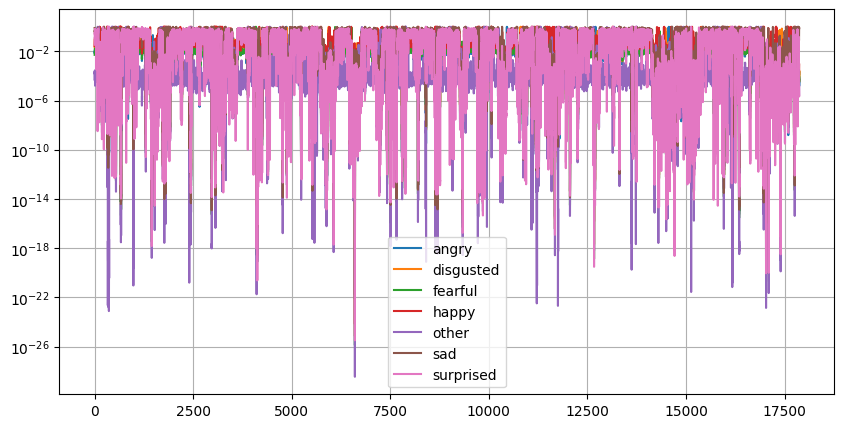

In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
for idx in range(scores.shape[1]):
    if 'neutral' in labels[idx] or 'unk' in labels[idx]:
        continue
    ax.plot(scores[:, idx], label=labels[idx])
# lines = ax.plot(scores) # Plots all columns at once
ax.legend() # Map the list of labels to the created lines
ax.grid(True)
ax.set_yscale("log")
plt.show()


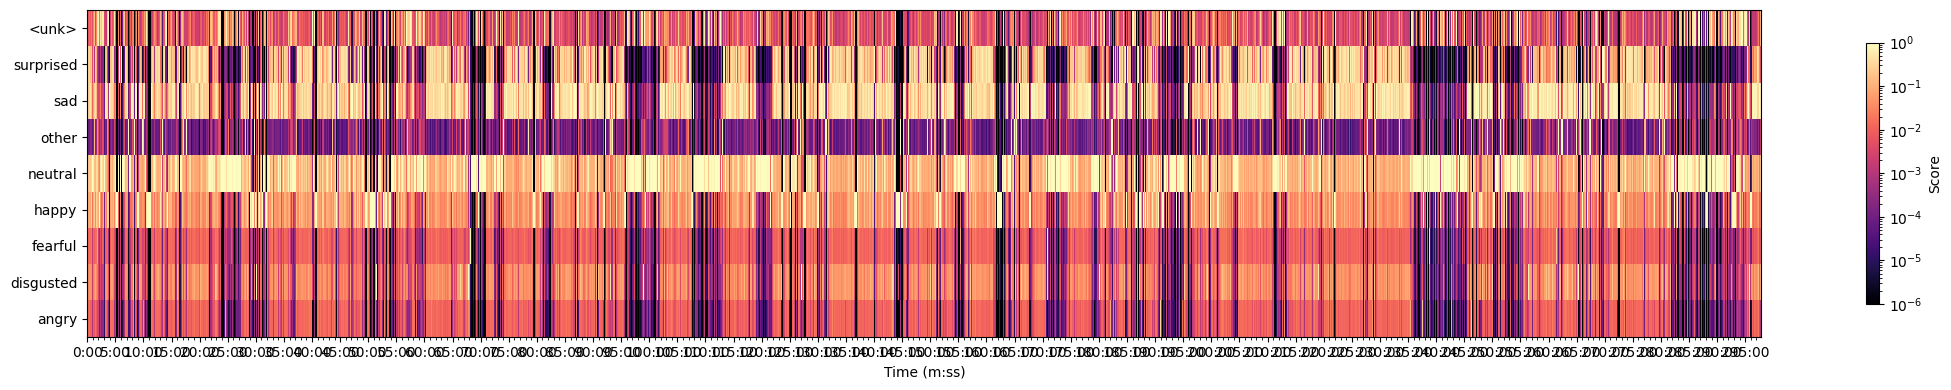

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm

hop_sec = 1.0
n_windows = scores.shape[0]

time_edges = np.arange(n_windows + 1) * hop_sec
label_edges = np.arange(len(labels) + 1)

fig, ax = plt.subplots(figsize=(22, 4))
mesh = ax.pcolormesh(
    time_edges, label_edges, scores.T,
    cmap="magma",
    norm=LogNorm(vmin=1e-6, vmax=1),
)

ax.set_yticks(np.arange(len(labels)) + 0.5)
ax.set_yticklabels(labels)

def fmt_time(x, _):
    m, s = divmod(int(x), 60)
    return f"{m}:{s:02d}"

ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_time))
ax.xaxis.set_major_locator(ticker.MultipleLocator(300))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(60))
ax.set_xlabel("Time (m:ss)")

fig.colorbar(mesh, ax=ax, label="Score", shrink=0.8)
plt.tight_layout()
plt.show()

In [17]:
res = model.generate(
    input=batch,
    fs=16000,
    granularity="utterance",
    extract_embedding=False,
)

rtf_avg: 0.051: 100%|██████████| 10/10 [00:01<00:00,  9.77it/s]                                                                                      


In [18]:
res

[{'key': 'rand_key_2yW4Acq9GFz6Y',
  'labels': ['生气/angry',
   '厌恶/disgusted',
   '恐惧/fearful',
   '开心/happy',
   '中立/neutral',
   '其他/other',
   '难过/sad',
   '吃惊/surprised',
   '<unk>'],
  'scores': [8.726299824957096e-07,
   2.104871327901492e-06,
   4.79837126476923e-06,
   2.3356566089205444e-05,
   0.9999545812606812,
   3.6768184941138315e-08,
   7.252507657540264e-06,
   5.2885279728798196e-06,
   1.809293848964444e-06]},
 {'key': 'rand_key_2yW4Acq9GFz6Y',
  'labels': ['生气/angry',
   '厌恶/disgusted',
   '恐惧/fearful',
   '开心/happy',
   '中立/neutral',
   '其他/other',
   '难过/sad',
   '吃惊/surprised',
   '<unk>'],
  'scores': [1.1675102541630622e-05,
   2.148649946320802e-05,
   3.109378303634003e-05,
   0.9910483956336975,
   0.00013521565415430814,
   6.072374162613414e-05,
   3.4670425520744175e-05,
   2.3401678390655434e-06,
   0.00865436252206564]},
 {'key': 'rand_key_2yW4Acq9GFz6Y',
  'labels': ['生气/angry',
   '厌恶/disgusted',
   '恐惧/fearful',
   '开心/happy',
   '中立/neutral',
   '其他

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

time_sec = np.arange(len(emotion_probs)) * HOP_SEC
time_min = time_sec / 60.0

def format_min_tick(x, _):
    """Display as M:SS"""
    m, s = divmod(int(x * 60), 60)
    return f"{m}:{s:02d}"

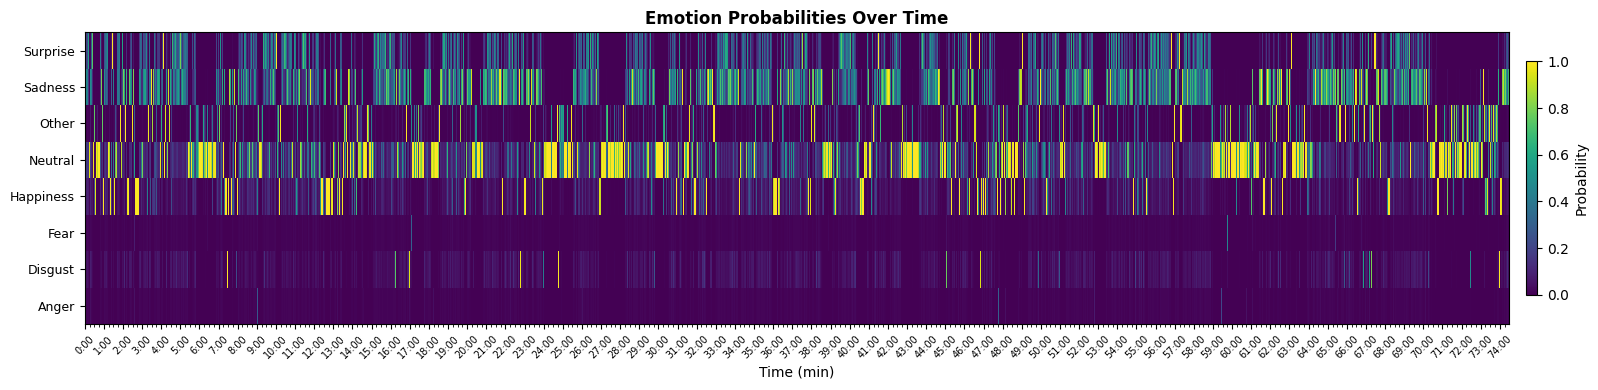

In [15]:
fig, ax = plt.subplots(figsize=(18, 4))
im = ax.imshow(
    emotion_probs.numpy().T,
    aspect="auto",
    interpolation="none",
    origin="lower",
    cmap="viridis",
    extent=[time_min[0], time_min[-1], -0.5, len(emotion_list) - 0.5],
)
ax.set_yticks(range(len(emotion_list)))
ax.set_yticklabels(emotion_list, fontsize=9)
ax.set_xlabel("Time (min)", fontsize=10)
ax.set_title("Emotion Probabilities Over Time", fontsize=12, fontweight="bold")

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))      # major every 1 min
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))   # minor every 15 sec
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_min_tick))
ax.tick_params(axis="x", which="major", labelsize=7, rotation=45)
ax.tick_params(axis="x", which="minor", length=2)

fig.colorbar(im, ax=ax, label="Probability", shrink=0.8, pad=0.01)
plt.tight_layout()
plt.show()

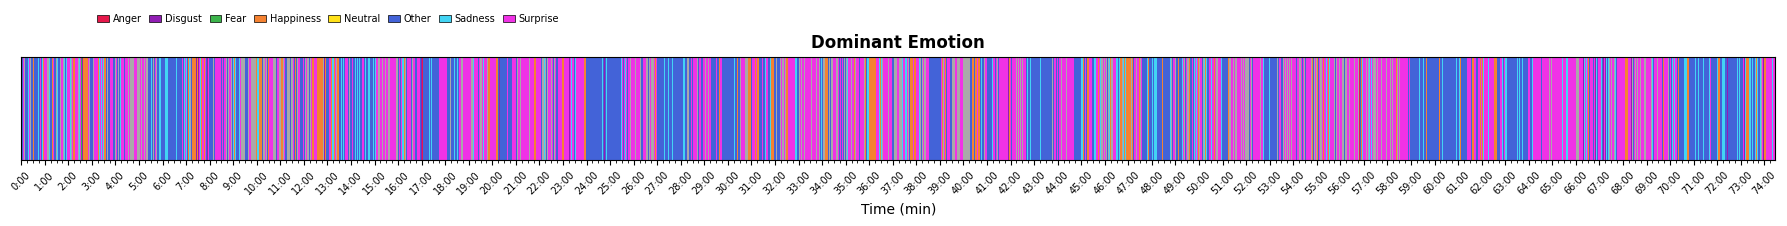

In [16]:
dominant_idx = emotion_probs.argmax(dim=-1).numpy()

# hand-picked distinct colors for 9 emotions — better than tab10 for adjacent bands
emotion_colors = [
    "#e6194b",  # Anger – red
    "#911eb4",  # Contempt – purple
    "#3cb44b",  # Disgust – green
    "#f58231",  # Fear – orange
    "#ffe119",  # Happiness – yellow
    "#4363d8",  # Neutral – blue
    "#42d4f4",  # Sadness – cyan
    "#f032e6",  # Surprise – magenta
    "#a9a9a9",  # Other – grey
]
from matplotlib.colors import ListedColormap
cmap_emo = ListedColormap(emotion_colors)

fig, ax = plt.subplots(figsize=(18, 3))

# draw as a colored bar, one pixel per window
ax.imshow(
    dominant_idx[None, :],
    aspect="auto",
    interpolation="nearest",
    cmap=cmap_emo,
    vmin=0,
    vmax=len(emotion_list) - 1,
    extent=[time_min[0], time_min[-1], 0, 1],
)
ax.set_yticks([])

# dense minute-level x ticks
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_min_tick))
ax.tick_params(axis="x", which="major", labelsize=7, rotation=45)
ax.tick_params(axis="x", which="minor", length=2)

ax.set_xlabel("Time (min)", fontsize=10)
ax.set_title("Dominant Emotion", fontsize=12, fontweight="bold")

# legend with matching colors — horizontal, compact
patches = [mpatches.Patch(facecolor=c, edgecolor="black", linewidth=0.5, label=e)
           for c, e in zip(emotion_colors, emotion_list)]
ax.legend(handles=patches, loc="lower center", bbox_to_anchor=(0.5, 1.02),
          ncol=len(emotion_list), fontsize=7, frameon=False,
          handlelength=1.2, handletextpad=0.4, columnspacing=0.8)
# Move legend to the top, right above the plot, as a horizontal band to avoid overlap
ax.legend(
    handles=patches,
    loc="upper center",
    bbox_to_anchor=(0.175, 1.5),
    ncol=len(emotion_list),
    fontsize=7,
    frameon=False,
    handlelength=1.2,
    handletextpad=0.4,
    columnspacing=0.8
)

plt.tight_layout()
plt.show()

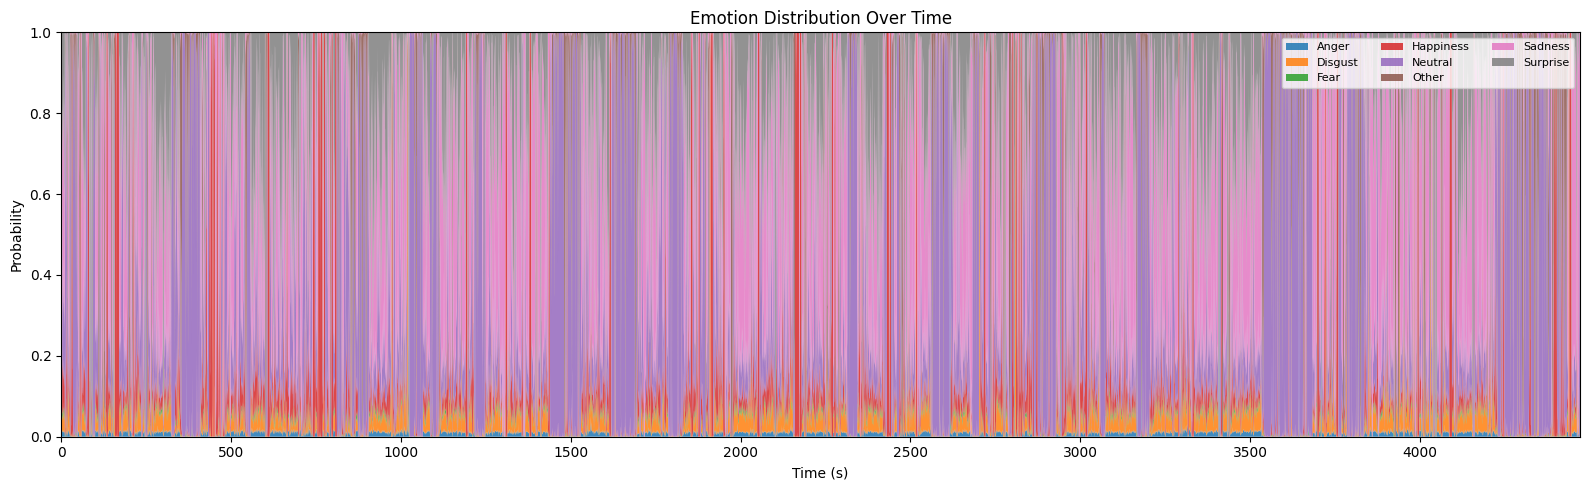

In [19]:
fig, ax = plt.subplots(figsize=(16, 5))
probs_np = emotion_probs.numpy()  # [N, 9]

duration_sec = len(audio) / SR  # where `audio` is the waveform and `sr` is the sample rate
num_frames = probs_np.shape[0]
time_axis = np.linspace(0, duration_sec, num_frames)

ax.stackplot(
    time_axis,
    probs_np.T,                    # each row is one emotion's time series
    labels=emotion_list,
    alpha=0.85,
)
ax.set_xlim(time_axis[0], time_axis[-1])
ax.set_ylim(0, 1)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Probability")


ax.set_title("Emotion Distribution Over Time")
ax.legend(loc="upper right", fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

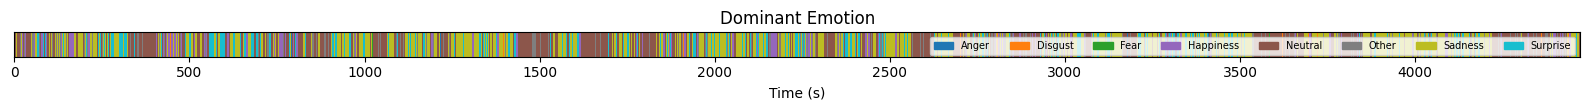

In [20]:
dominant_idx = emotion_probs.argmax(dim=-1).numpy()  # [N]

cmap = plt.cm.get_cmap("tab10", len(emotion_list))
fig, ax = plt.subplots(figsize=(16, 1.2))
ax.imshow(
    dominant_idx[None, :],          # [1, N]
    aspect="auto",
    interpolation="nearest",
    cmap=cmap,
    vmin=0, vmax=len(emotion_list) - 1,
    extent=[time_axis[0], time_axis[-1], 0, 1],
)
ax.set_yticks([])
ax.set_xlabel("Time (s)")
ax.set_title("Dominant Emotion")

# legend
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=cmap(i), label=e) for i, e in enumerate(emotion_list)]
ax.legend(handles=patches, loc="upper right", fontsize=7, ncol=len(emotion_list))
plt.tight_layout()
plt.show()

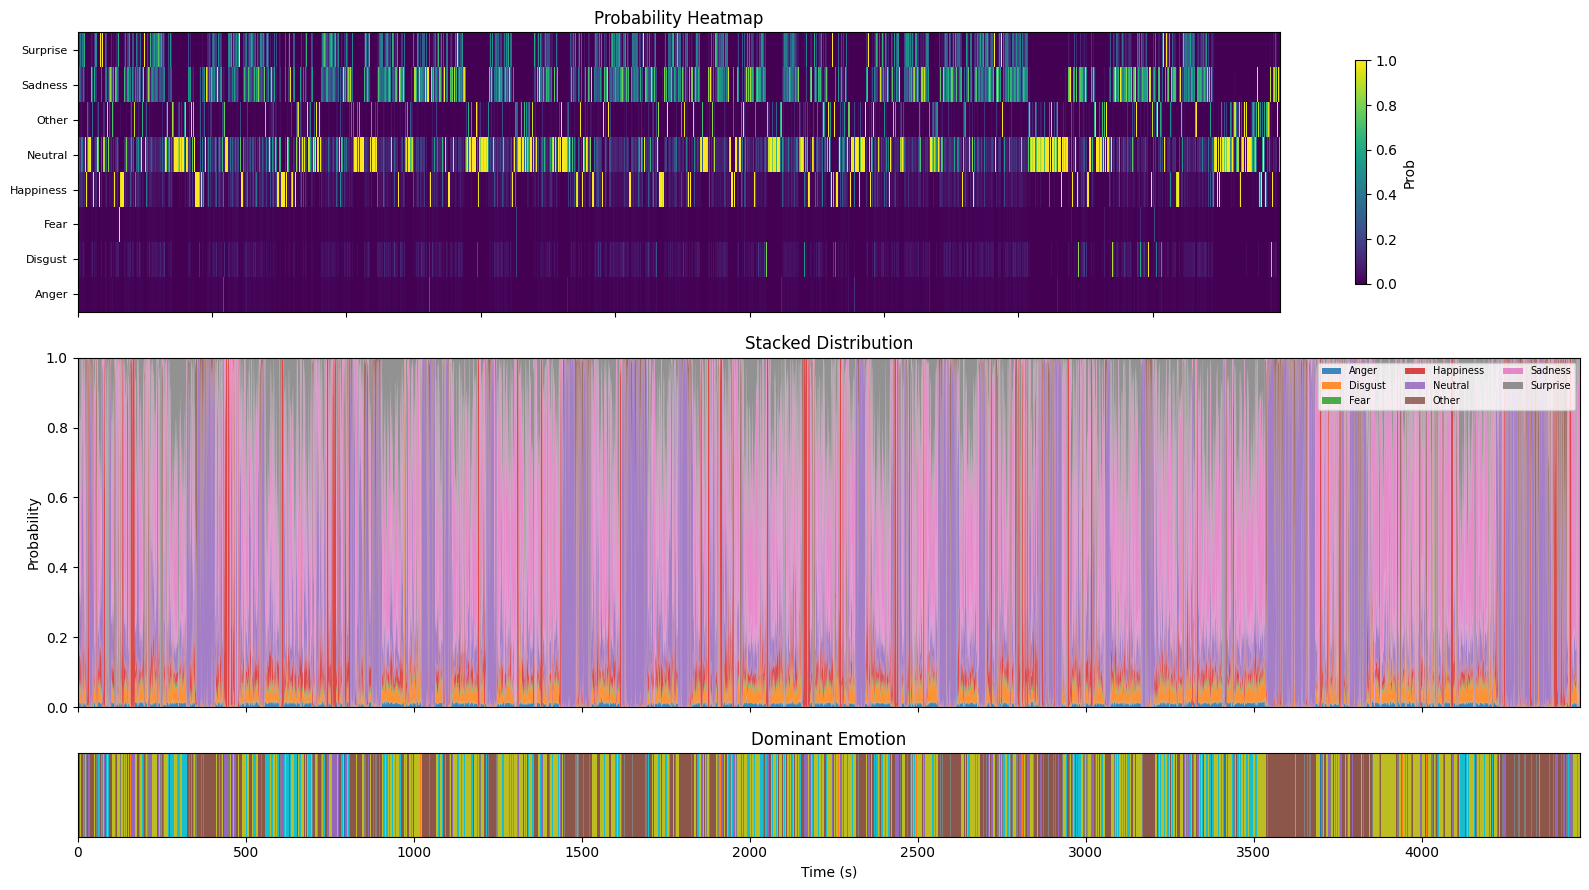

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True,
                         gridspec_kw={"height_ratios": [4, 5, 1.2]})

# -- heatmap --
im = axes[0].imshow(emotion_probs.numpy().T, aspect="auto", interpolation="none",
                    origin="lower", cmap="viridis",
                    extent=[time_axis[0], time_axis[-1], -0.5, len(emotion_list)-0.5])
axes[0].set_yticks(range(len(emotion_list)))
axes[0].set_yticklabels(emotion_list, fontsize=8)
axes[0].set_title("Probability Heatmap")
fig.colorbar(im, ax=axes[0], shrink=0.8, label="Prob")

# -- stacked area --
axes[1].stackplot(time_axis, emotion_probs.numpy().T, labels=emotion_list, alpha=0.85)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Probability")
axes[1].set_title("Stacked Distribution")
axes[1].legend(loc="upper right", fontsize=7, ncol=3)

# -- dominant strip --
cmap_dom = plt.cm.get_cmap("tab10", len(emotion_list))
axes[2].imshow(dominant_idx[None, :], aspect="auto", interpolation="nearest",
               cmap=cmap_dom, vmin=0, vmax=len(emotion_list)-1,
               extent=[time_axis[0], time_axis[-1], 0, 1])
axes[2].set_yticks([])
axes[2].set_title("Dominant Emotion")
axes[2].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

In [22]:
# --- Cell 1: class partition + cached summary stats ---
import numpy as np

probs_np = emotion_probs.numpy()           # [N, 9]
N, K = probs_np.shape

UNINTERESTING = {"Neutral", "Other"}
interesting_idx    = [i for i, e in enumerate(emotion_list) if e not in UNINTERESTING]
uninteresting_idx  = [i for i, e in enumerate(emotion_list) if e in UNINTERESTING]
interesting_labels = [emotion_list[i] for i in interesting_idx]

dominant_idx = probs_np.argmax(axis=-1)
top1_prob    = probs_np.max(axis=-1)
sorted_p     = np.sort(probs_np, axis=-1)
margin       = sorted_p[:, -1] - sorted_p[:, -2]
is_interesting_top1 = np.isin(dominant_idx, interesting_idx)

# canonical time axis (window centers)
window_centers_sec = np.arange(N) * HOP_SEC + WINDOW_SEC / 2
window_centers_min = window_centers_sec / 60.0

print(f"windows: {N}   duration: {window_centers_sec[-1]/60:.1f} min")
print(f"argmax is an interesting class in "
      f"{is_interesting_top1.sum()} / {N} windows ({100*is_interesting_top1.mean():.1f}%)")
print(f"top1_prob:   mean={top1_prob.mean():.2f}, median={np.median(top1_prob):.2f}, "
      f"min={top1_prob.min():.2f}, max={top1_prob.max():.2f}")
print(f"margin:      mean={margin.mean():.2f},   median={np.median(margin):.2f}, "
      f"min={margin.min():.2f},   max={margin.max():.2f}")

windows: 17873   duration: 74.5 min
argmax is an interesting class in 10551 / 17873 windows (59.0%)
top1_prob:   mean=0.69, median=0.67, min=0.21, max=1.00
margin:      mean=0.53,   median=0.49, min=0.00,   max=1.00


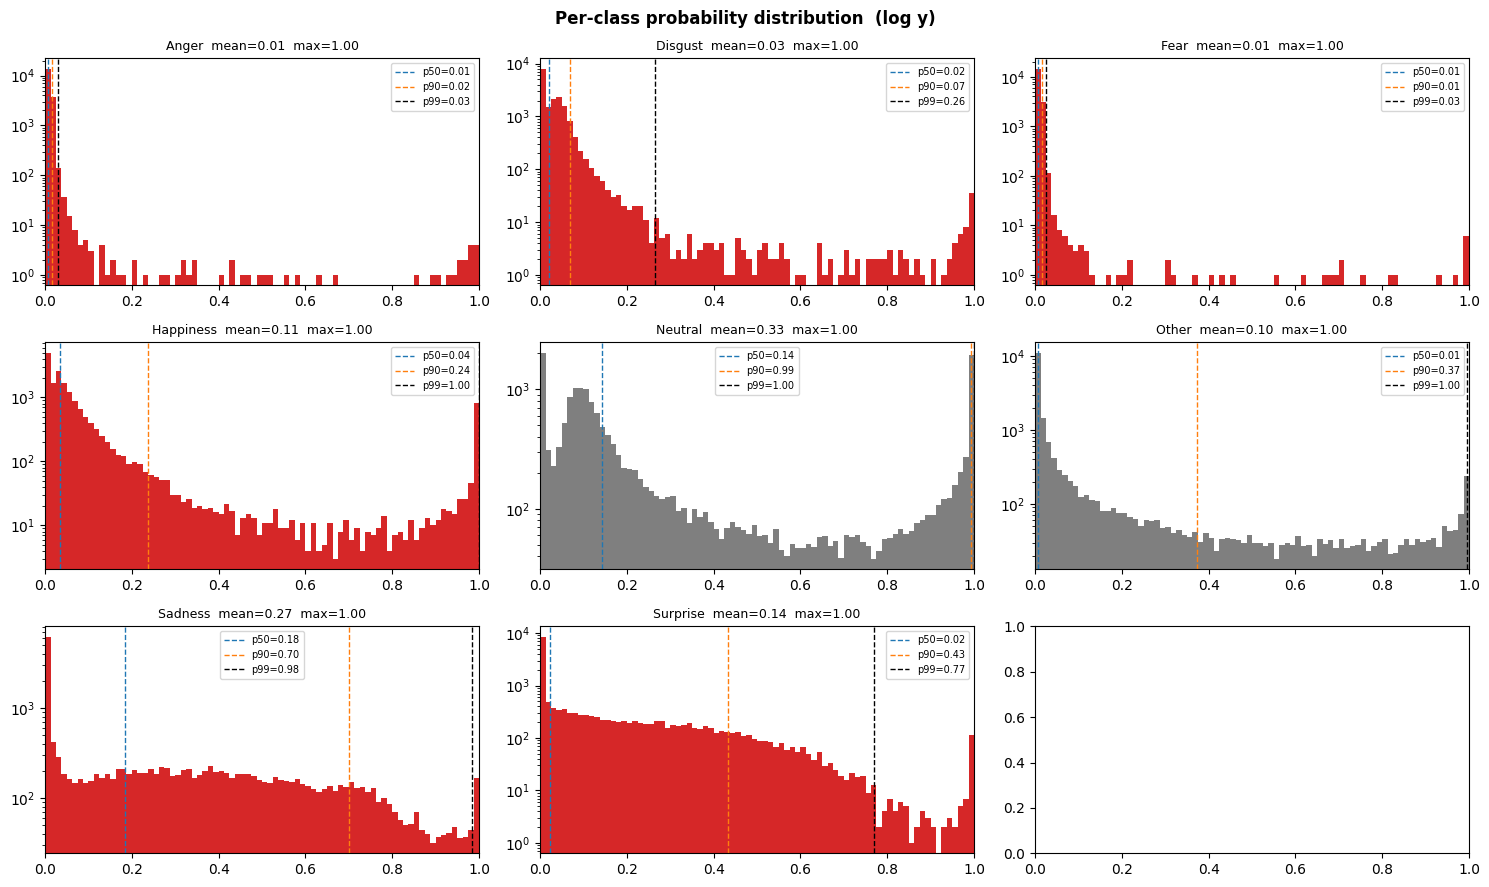

In [23]:
# --- Cell 2: per-class probability baselines (log y, with quantile lines) ---
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for i, label in enumerate(emotion_list):
    ax = axes[i // 3, i % 3]
    vals = probs_np[:, i]
    ax.hist(vals, bins=80, log=True,
            color=("tab:gray" if label in UNINTERESTING else "tab:red"))
    q50, q90, q99 = np.quantile(vals, [0.5, 0.9, 0.99])
    for q, c, lbl in [(q50, "tab:blue", "p50"),
                      (q90, "tab:orange", "p90"),
                      (q99, "black", "p99")]:
        ax.axvline(q, color=c, linestyle="--", linewidth=1, label=f"{lbl}={q:.2f}")
    ax.set_title(f"{label}  mean={vals.mean():.2f}  max={vals.max():.2f}", fontsize=9)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=7)
fig.suptitle("Per-class probability distribution  (log y)", fontweight="bold")
plt.tight_layout(); plt.show()

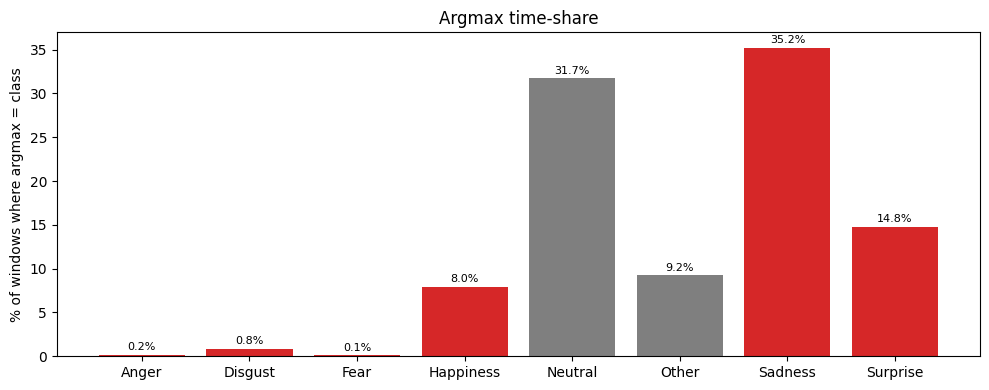

In [24]:
# --- Cell 3: argmax time-share per class ---
counts = np.bincount(dominant_idx, minlength=K)
shares = counts / N

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["tab:gray" if e in UNINTERESTING else "tab:red" for e in emotion_list]
bars = ax.bar(emotion_list, 100 * shares, color=colors)
for b, s in zip(bars, shares):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
            f"{100*s:.1f}%", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("% of windows where argmax = class")
ax.set_title("Argmax time-share")
plt.tight_layout(); plt.show()

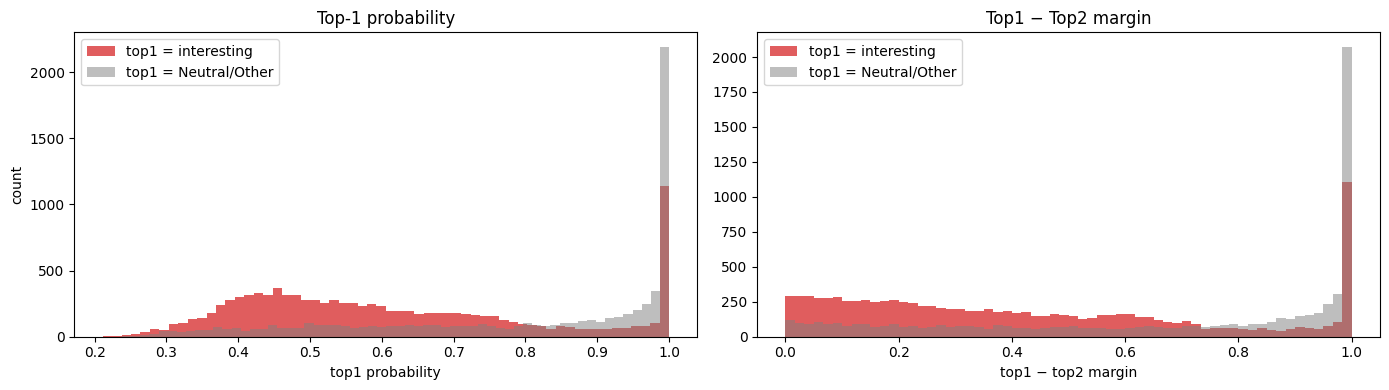

In [25]:
# --- Cell 4: top1 prob and top1-top2 margin, split by 'interesting top1' ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(top1_prob[is_interesting_top1],  bins=60, alpha=0.75,
             label="top1 = interesting", color="tab:red")
axes[0].hist(top1_prob[~is_interesting_top1], bins=60, alpha=0.5,
             label="top1 = Neutral/Other", color="tab:gray")
axes[0].set_xlabel("top1 probability"); axes[0].set_ylabel("count"); axes[0].legend()
axes[0].set_title("Top-1 probability")

axes[1].hist(margin[is_interesting_top1],  bins=60, alpha=0.75,
             label="top1 = interesting", color="tab:red")
axes[1].hist(margin[~is_interesting_top1], bins=60, alpha=0.5,
             label="top1 = Neutral/Other", color="tab:gray")
axes[1].set_xlabel("top1 − top2 margin"); axes[1].legend()
axes[1].set_title("Top1 − Top2 margin")

plt.tight_layout(); plt.show()

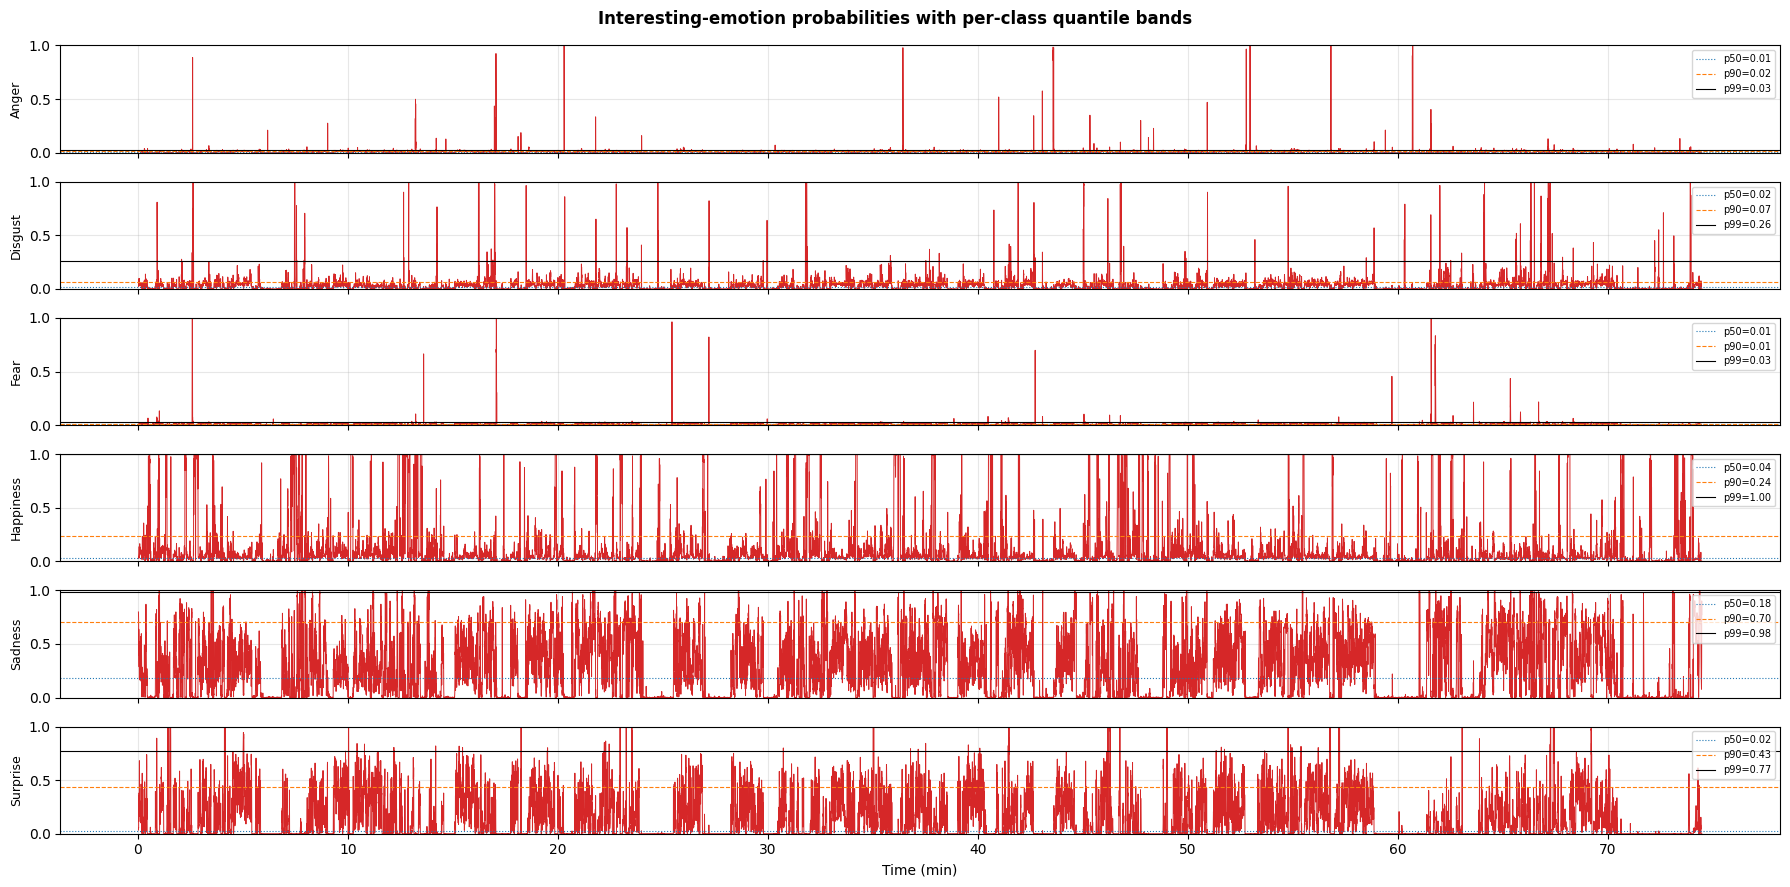

In [26]:
# --- Cell 5: per-emotion line plot with self-quantile reference lines ---
fig, axes = plt.subplots(len(interesting_idx), 1,
                         figsize=(18, 1.5 * len(interesting_idx)), sharex=True)

for ax, ci, lbl in zip(axes, interesting_idx, interesting_labels):
    vals = probs_np[:, ci]
    q50, q90, q99 = np.quantile(vals, [0.5, 0.9, 0.99])
    ax.plot(window_centers_min, vals, color="tab:red", linewidth=0.7)
    ax.axhline(q50, color="tab:blue",   linestyle=":",  linewidth=0.8, label=f"p50={q50:.2f}")
    ax.axhline(q90, color="tab:orange", linestyle="--", linewidth=0.8, label=f"p90={q90:.2f}")
    ax.axhline(q99, color="black",      linestyle="-",  linewidth=0.8, label=f"p99={q99:.2f}")
    ax.set_ylabel(lbl, fontsize=9)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="upper right")

axes[-1].set_xlabel("Time (min)")
fig.suptitle("Interesting-emotion probabilities with per-class quantile bands",
             fontweight="bold")
plt.tight_layout(); plt.show()

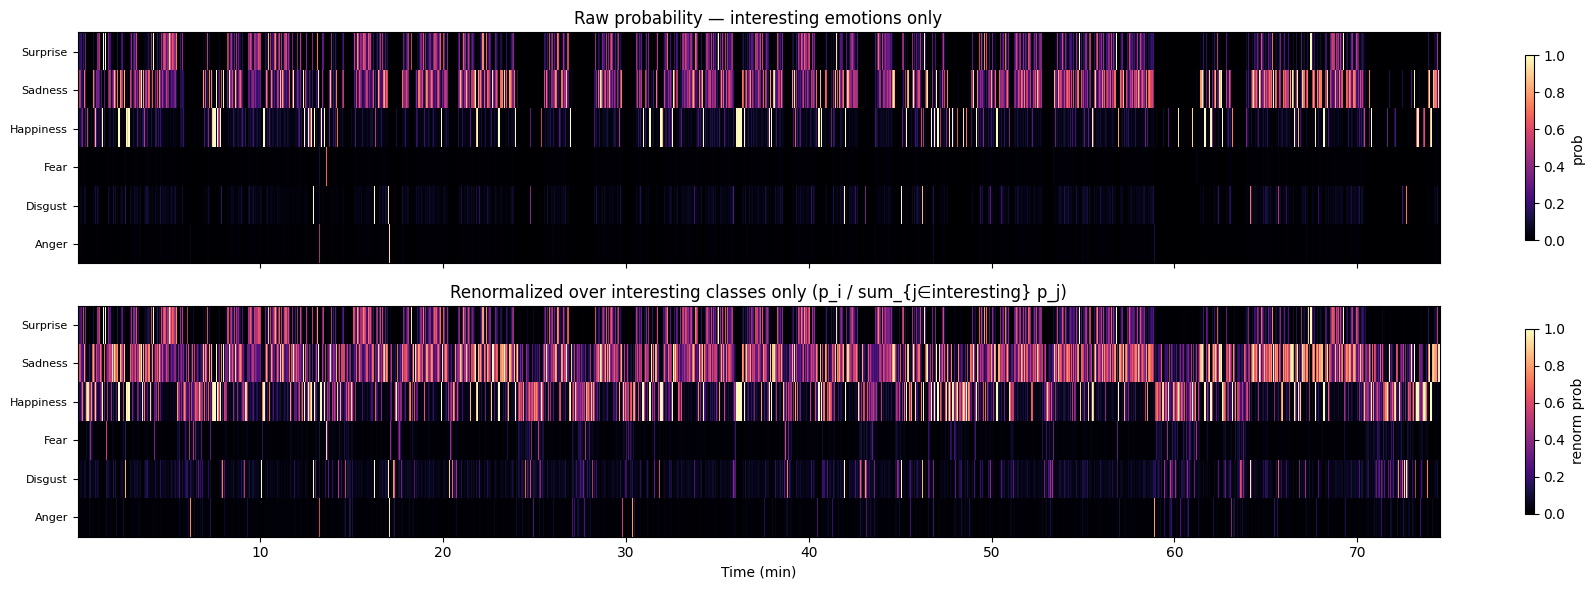

In [27]:
# --- Cell 6: suppressed-Neutral/Other heatmap (raw + renormalized over 7 classes) ---
interesting_probs = probs_np[:, interesting_idx]                       # [N, 7]
mass = interesting_probs.sum(axis=-1, keepdims=True)
renorm = np.where(mass > 1e-9, interesting_probs / mass, 0.0)          # [N, 7]

fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=True)

im0 = axes[0].imshow(interesting_probs.T, aspect="auto", interpolation="none",
                     origin="lower", cmap="magma",
                     extent=[window_centers_min[0], window_centers_min[-1],
                             -0.5, len(interesting_idx)-0.5])
axes[0].set_yticks(range(len(interesting_idx)))
axes[0].set_yticklabels(interesting_labels, fontsize=8)
axes[0].set_title("Raw probability — interesting emotions only")
fig.colorbar(im0, ax=axes[0], shrink=0.8, label="prob")

im1 = axes[1].imshow(renorm.T, aspect="auto", interpolation="none",
                     origin="lower", cmap="magma",
                     extent=[window_centers_min[0], window_centers_min[-1],
                             -0.5, len(interesting_idx)-0.5])
axes[1].set_yticks(range(len(interesting_idx)))
axes[1].set_yticklabels(interesting_labels, fontsize=8)
axes[1].set_title("Renormalized over interesting classes only "
                  "(p_i / sum_{j∈interesting} p_j)")
axes[1].set_xlabel("Time (min)")
fig.colorbar(im1, ax=axes[1], shrink=0.8, label="renorm prob")

plt.tight_layout(); plt.show()

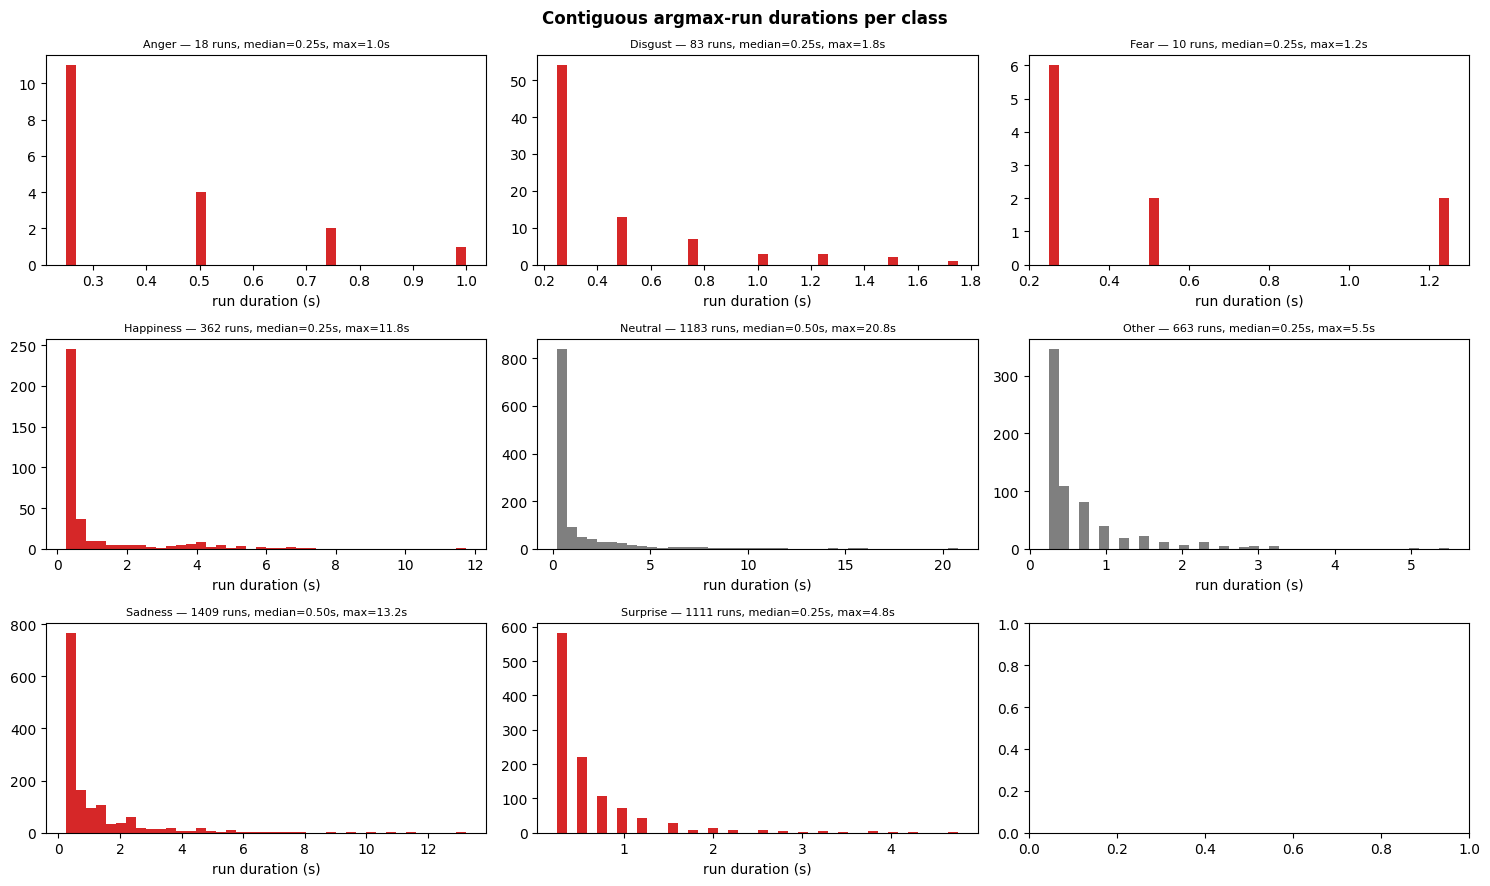

In [28]:
# --- Cell 7: run-length distribution of argmax, per class ---
def run_lengths(arr):
    if len(arr) == 0:
        return np.array([]), np.array([])
    bnd = np.concatenate([[0], np.where(np.diff(arr) != 0)[0] + 1, [len(arr)]])
    return arr[bnd[:-1]], np.diff(bnd)

run_vals, run_lens = run_lengths(dominant_idx)
run_durs_sec = run_lens * HOP_SEC

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for i, label in enumerate(emotion_list):
    ax = axes[i // 3, i % 3]
    durs = run_durs_sec[run_vals == i]
    color = "tab:gray" if label in UNINTERESTING else "tab:red"
    if len(durs) == 0:
        ax.set_title(f"{label} — no runs", fontsize=9)
        ax.set_axis_off()
        continue
    ax.hist(durs, bins=40, color=color)
    ax.set_title(f"{label} — {len(durs)} runs, "
                 f"median={np.median(durs):.2f}s, max={durs.max():.1f}s", fontsize=8)
    ax.set_xlabel("run duration (s)")
fig.suptitle("Contiguous argmax-run durations per class", fontweight="bold")
plt.tight_layout(); plt.show()

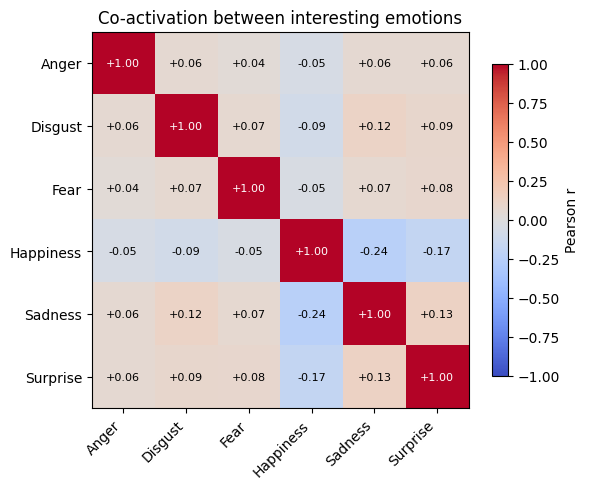

In [29]:
# --- Cell 8: pairwise correlation between interesting-class probabilities ---
import pandas as pd

df = pd.DataFrame(interesting_probs, columns=interesting_labels)
corr = df.corr(method="pearson").values

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(interesting_labels)))
ax.set_xticklabels(interesting_labels, rotation=45, ha="right")
ax.set_yticks(range(len(interesting_labels)))
ax.set_yticklabels(interesting_labels)
for i in range(len(interesting_labels)):
    for j in range(len(interesting_labels)):
        ax.text(j, i, f"{corr[i, j]:+.2f}", ha="center", va="center", fontsize=8,
                color="black" if abs(corr[i, j]) < 0.6 else "white")
fig.colorbar(im, shrink=0.8, label="Pearson r")
ax.set_title("Co-activation between interesting emotions")
plt.tight_layout(); plt.show()

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

probs_np = emotion_probs.detach().cpu().numpy()
logits_np = all_predicted.detach().cpu().numpy()

N, K = probs_np.shape
assert K == len(emotion_list), (K, len(emotion_list))

UNINTERESTING = {"Neutral", "Other"}
interesting_idx = [i for i, label in enumerate(emotion_list) if label not in UNINTERESTING]
uninteresting_idx = [i for i, label in enumerate(emotion_list) if label in UNINTERESTING]
interesting_labels = [emotion_list[i] for i in interesting_idx]

frame_start_sec = np.arange(N) * HOP_SEC
frame_end_sec = frame_start_sec + WINDOW_SEC
frame_center_sec = frame_start_sec + WINDOW_SEC / 2
frame_center_min = frame_center_sec / 60

top1_idx = probs_np.argmax(axis=1)
top1_prob = probs_np.max(axis=1)

sorted_idx = np.argsort(probs_np, axis=1)
top2_idx = sorted_idx[:, -2]
top2_prob = probs_np[np.arange(N), top2_idx]
top1_margin = top1_prob - top2_prob

interesting_probs = probs_np[:, interesting_idx]
interesting_mass = interesting_probs.sum(axis=1)
uninteresting_mass = probs_np[:, uninteresting_idx].sum(axis=1)

best_interesting_local_idx = interesting_probs.argmax(axis=1)
best_interesting_idx = np.array(interesting_idx)[best_interesting_local_idx]
best_interesting_prob = probs_np[np.arange(N), best_interesting_idx]

interesting_margin_vs_background = best_interesting_prob - probs_np[:, uninteresting_idx].max(axis=1)
is_top1_interesting = np.isin(top1_idx, interesting_idx)

entropy = -(probs_np * np.log(np.clip(probs_np, 1e-12, 1))).sum(axis=1)

print(f"frames: {N}")
print(f"audio duration from frames: {frame_end_sec[-1] / 60:.2f} min")
print(f"prob shape: {probs_np.shape}")
print(f"logit shape: {logits_np.shape}")
print()
print(f"top1 interesting frames: {is_top1_interesting.sum()} / {N} ({100 * is_top1_interesting.mean():.1f}%)")
print(f"interesting mass: median={np.median(interesting_mass):.3f}, p90={np.quantile(interesting_mass, 0.90):.3f}, max={interesting_mass.max():.3f}")
print(f"top1 probability: median={np.median(top1_prob):.3f}, p90={np.quantile(top1_prob, 0.90):.3f}, max={top1_prob.max():.3f}")
print(f"top1 margin: median={np.median(top1_margin):.3f}, p90={np.quantile(top1_margin, 0.90):.3f}, max={top1_margin.max():.3f}")
print(f"entropy: median={np.median(entropy):.3f}, p90={np.quantile(entropy, 0.90):.3f}")


frames: 17873
audio duration from frames: 74.52 min
prob shape: (17873, 8)
logit shape: (17873, 8)

top1 interesting frames: 10551 / 17873 (59.0%)
interesting mass: median=0.782, p90=0.953, max=1.000
top1 probability: median=0.666, p90=1.000, max=1.000
top1 margin: median=0.493, p90=1.000, max=1.000
entropy: median=1.005, p90=1.508


In [31]:
rows = []
for i, label in enumerate(emotion_list):
    vals = probs_np[:, i]
    argmax_mask = top1_idx == i
    rows.append({
        "label": label,
        "interesting": label not in UNINTERESTING,
        "mean_prob": vals.mean(),
        "p50": np.quantile(vals, 0.50),
        "p75": np.quantile(vals, 0.75),
        "p90": np.quantile(vals, 0.90),
        "p95": np.quantile(vals, 0.95),
        "p99": np.quantile(vals, 0.99),
        "max": vals.max(),
        "argmax_frames": int(argmax_mask.sum()),
        "argmax_share_pct": 100 * argmax_mask.mean(),
    })

class_stats = pd.DataFrame(rows).sort_values(["interesting", "argmax_share_pct"], ascending=[False, False])
display(class_stats)


,label,interesting,mean_prob,p50,p75,p90,p95,p99,max,argmax_frames,argmax_share_pct
6,Sadness,True,0.265771,0.184081,0.472756,0.701191,0.794715,0.983954,1.000000,6294,35.215129
7,Surprise,True,0.137035,0.021944,0.234191,0.433742,0.540905,0.768781,1.000000,2638,14.759693
3,Happiness,True,0.113988,0.035509,0.081867,0.236914,0.958490,1.000000,1.000000,1423,7.961730
1,Disgust,True,0.034469,0.020408,0.046201,0.067979,0.092865,0.263824,1.000000,147,0.822470
0,Anger,True,0.008438,0.006628,0.012079,0.015061,0.017269,0.029828,0.999874,29,0.162256
2,Fear,True,0.008057,0.007185,0.011404,0.014876,0.017577,0.025309,0.999816,20,0.111901
4,Neutral,False,0.331883,0.142653,0.581858,0.992247,0.999863,1.000000,1.000000,5674,31.746209
5,Other,False,0.100359,0.005864,0.042059,0.373643,0.745167,0.995090,0.999991,1648,9.220612


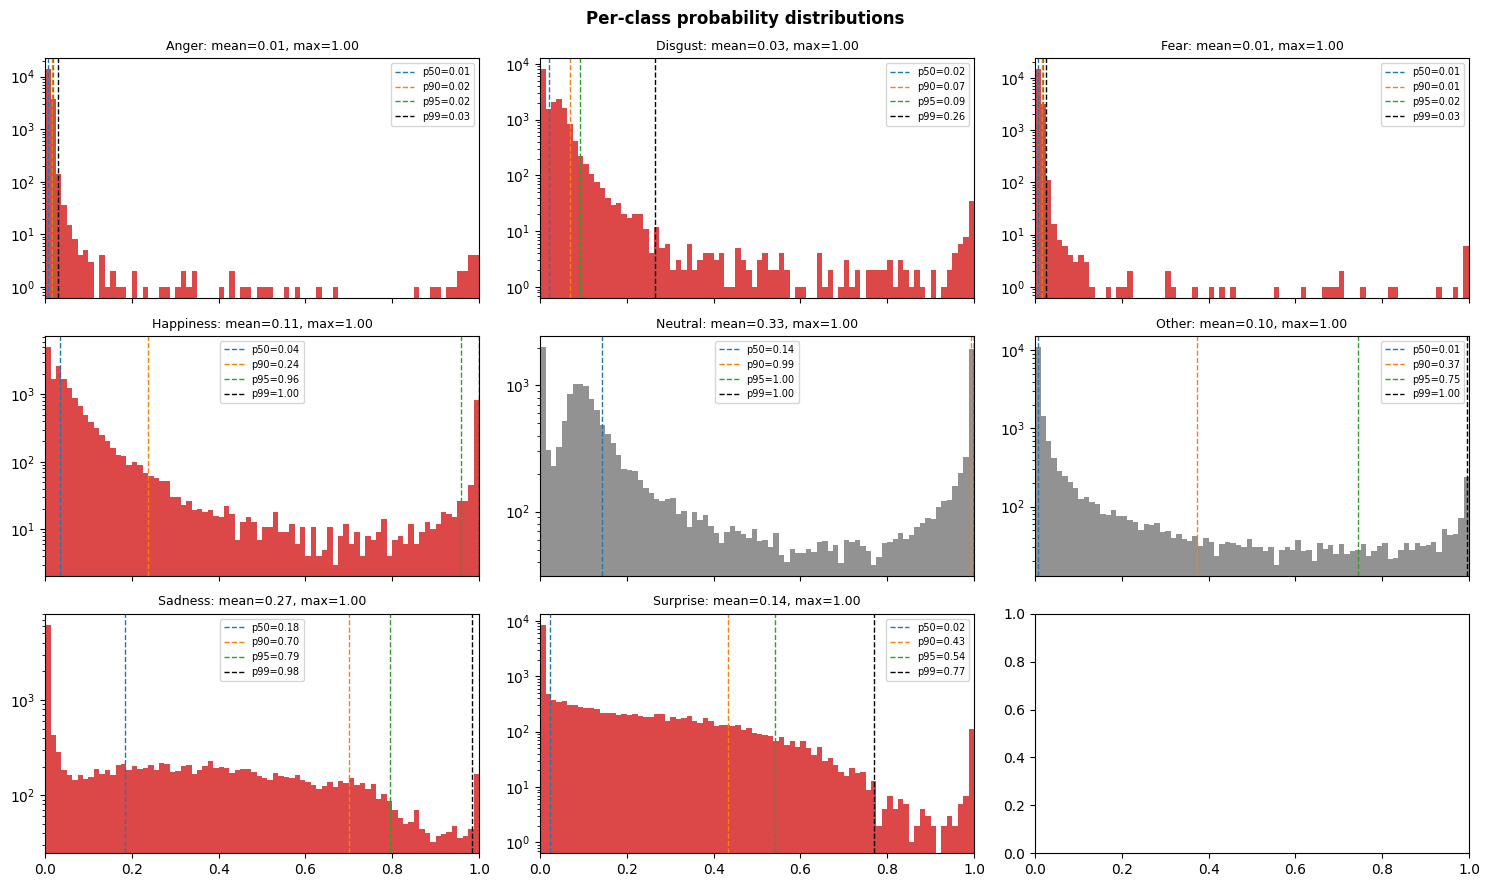

In [32]:
fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharex=True)

for i, label in enumerate(emotion_list):
    ax = axes[i // 3, i % 3]
    vals = probs_np[:, i]
    color = "tab:gray" if label in UNINTERESTING else "tab:red"

    ax.hist(vals, bins=80, color=color, alpha=0.85, log=True)
    for q, name, line_color in [
        (0.50, "p50", "tab:blue"),
        (0.90, "p90", "tab:orange"),
        (0.95, "p95", "tab:green"),
        (0.99, "p99", "black"),
    ]:
        v = np.quantile(vals, q)
        ax.axvline(v, color=line_color, linestyle="--", linewidth=1, label=f"{name}={v:.2f}")

    ax.set_title(f"{label}: mean={vals.mean():.2f}, max={vals.max():.2f}", fontsize=9)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=7)

fig.suptitle("Per-class probability distributions", fontweight="bold")
plt.tight_layout()
plt.show()


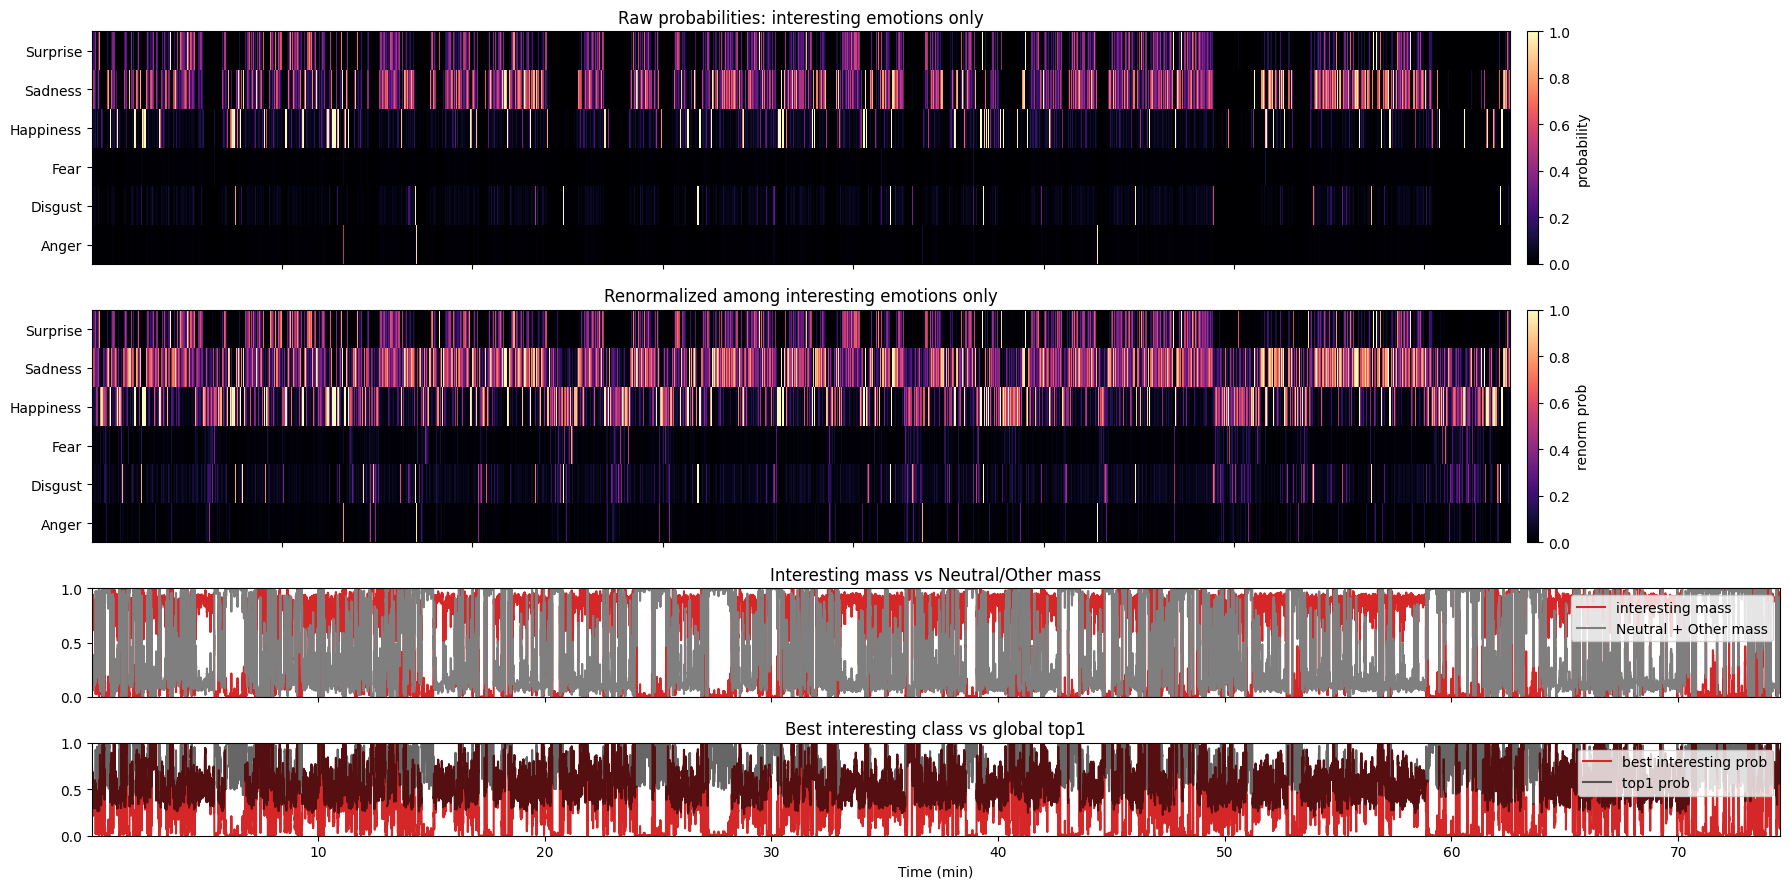

In [33]:
renorm_interesting_probs = interesting_probs / np.clip(interesting_mass[:, None], 1e-9, None)

fig, axes = plt.subplots(4, 1, figsize=(18, 9), sharex=True,
                         gridspec_kw={"height_ratios": [3, 3, 1.4, 1.2]})

im0 = axes[0].imshow(
    interesting_probs.T,
    aspect="auto",
    interpolation="none",
    origin="lower",
    cmap="magma",
    extent=[frame_center_min[0], frame_center_min[-1], -0.5, len(interesting_labels) - 0.5],
)
axes[0].set_yticks(range(len(interesting_labels)))
axes[0].set_yticklabels(interesting_labels)
axes[0].set_title("Raw probabilities: interesting emotions only")
fig.colorbar(im0, ax=axes[0], label="probability", pad=0.01)

im1 = axes[1].imshow(
    renorm_interesting_probs.T,
    aspect="auto",
    interpolation="none",
    origin="lower",
    cmap="magma",
    extent=[frame_center_min[0], frame_center_min[-1], -0.5, len(interesting_labels) - 0.5],
)
axes[1].set_yticks(range(len(interesting_labels)))
axes[1].set_yticklabels(interesting_labels)
axes[1].set_title("Renormalized among interesting emotions only")
fig.colorbar(im1, ax=axes[1], label="renorm prob", pad=0.01)

axes[2].plot(frame_center_min, interesting_mass, color="tab:red", label="interesting mass")
axes[2].plot(frame_center_min, uninteresting_mass, color="tab:gray", label="Neutral + Other mass")
axes[2].set_ylim(0, 1)
axes[2].legend(loc="upper right")
axes[2].set_title("Interesting mass vs Neutral/Other mass")

axes[3].plot(frame_center_min, best_interesting_prob, color="tab:red", label="best interesting prob")
axes[3].plot(frame_center_min, top1_prob, color="black", alpha=0.6, label="top1 prob")
axes[3].set_ylim(0, 1)
axes[3].legend(loc="upper right")
axes[3].set_title("Best interesting class vs global top1")

axes[-1].set_xlabel("Time (min)")
plt.tight_layout()
plt.show()


In [34]:
def segments_from_mask(mask, min_duration_sec=1.0, merge_gap_sec=0.75):
    mask = np.asarray(mask, dtype=bool)
    bounds = np.concatenate([[0], np.where(np.diff(mask.astype(int)) != 0)[0] + 1, [len(mask)]])
    spans = [(s, e) for s, e in zip(bounds[:-1], bounds[1:]) if mask[s]]

    if not spans:
        return []

    max_gap_frames = int(np.ceil(merge_gap_sec / HOP_SEC))
    merged = [spans[0]]
    for s, e in spans[1:]:
        ps, pe = merged[-1]
        if s - pe <= max_gap_frames:
            merged[-1] = (ps, e)
        else:
            merged.append((s, e))

    min_frames = max(1, int(np.ceil(min_duration_sec / HOP_SEC)))
    return [(s, e) for s, e in merged if e - s >= min_frames]


def candidate_events(prob_thr=0.45, margin_thr=0.05, min_duration_sec=1.0, merge_gap_sec=0.75,
                     require_global_top1=True):
    events = []

    for class_idx, label in zip(interesting_idx, interesting_labels):
        class_prob = probs_np[:, class_idx]
        class_is_best_interesting = best_interesting_idx == class_idx

        mask = (
            class_is_best_interesting
            & (class_prob >= prob_thr)
            & (interesting_margin_vs_background >= margin_thr)
        )

        if require_global_top1:
            mask = mask & (top1_idx == class_idx)

        for s, e in segments_from_mask(mask, min_duration_sec=min_duration_sec, merge_gap_sec=merge_gap_sec):
            peak_rel = np.argmax(class_prob[s:e])
            peak_i = s + peak_rel

            top_at_peak = np.argsort(probs_np[peak_i])[::-1][:5]
            events.append({
                "label": label,
                "start_sec": frame_start_sec[s],
                "end_sec": frame_end_sec[e - 1],
                "duration_sec": frame_end_sec[e - 1] - frame_start_sec[s],
                "start_min": frame_start_sec[s] / 60,
                "end_min": frame_end_sec[e - 1] / 60,
                "peak_sec": frame_center_sec[peak_i],
                "peak_prob": class_prob[peak_i],
                "mean_prob": class_prob[s:e].mean(),
                "peak_margin_vs_top2": top1_margin[peak_i],
                "peak_margin_vs_background": interesting_margin_vs_background[peak_i],
                "interesting_mass_at_peak": interesting_mass[peak_i],
                "top_classes_at_peak": {emotion_list[j]: float(probs_np[peak_i, j]) for j in top_at_peak},
                "frame_start": int(s),
                "frame_end": int(e),
            })

    return pd.DataFrame(events).sort_values(["start_sec", "label"]).reset_index(drop=True)


sweep_rows = []
for prob_thr in [0.30, 0.35, 0.40, 0.45, 0.50, 0.60]:
    for margin_thr in [0.00, 0.05, 0.10, 0.15]:
        ev = candidate_events(
            prob_thr=prob_thr,
            margin_thr=margin_thr,
            min_duration_sec=1.0,
            merge_gap_sec=0.75,
            require_global_top1=True,
        )
        sweep_rows.append({
            "prob_thr": prob_thr,
            "margin_thr": margin_thr,
            "n_events": len(ev),
            "total_event_min": ev["duration_sec"].sum() / 60 if len(ev) else 0,
            "median_duration_sec": ev["duration_sec"].median() if len(ev) else np.nan,
            "p90_duration_sec": ev["duration_sec"].quantile(0.90) if len(ev) else np.nan,
            "labels": ev["label"].value_counts().to_dict() if len(ev) else {},
        })

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)


,prob_thr,margin_thr,n_events,total_event_min,median_duration_sec,p90_duration_sec,labels
0,0.30,0.00,744,83.362500,5.50,11.250,"{'Sadness': 358, 'Surprise': 267, 'Happiness':..."
1,0.30,0.05,737,82.100000,5.50,11.250,"{'Sadness': 357, 'Surprise': 263, 'Happiness':..."
2,0.30,0.10,724,80.445833,5.50,10.925,"{'Sadness': 355, 'Surprise': 257, 'Happiness':..."
3,0.30,0.15,706,78.000000,5.50,10.625,"{'Sadness': 354, 'Surprise': 243, 'Happiness':..."
4,0.35,0.00,727,80.258333,5.50,10.750,"{'Sadness': 355, 'Surprise': 257, 'Happiness':..."
5,0.35,0.05,726,79.887500,5.50,10.500,"{'Sadness': 356, 'Surprise': 256, 'Happiness':..."
6,0.35,0.10,718,78.929167,5.50,10.500,"{'Sadness': 356, 'Surprise': 251, 'Happiness':..."
7,0.35,0.15,703,77.233333,5.50,10.500,"{'Sadness': 354, 'Surprise': 240, 'Happiness':..."
8,0.40,0.00,692,74.225000,5.50,10.475,"{'Sadness': 354, 'Surprise': 224, 'Happiness':..."
9,0.40,0.05,691,74.087500,5.50,10.500,"{'Sadness': 355, 'Surprise': 223, 'Happiness':..."


In [35]:
PROB_THR = 0.45
MARGIN_THR = 0.05
MIN_DURATION_SEC = 1.0
MERGE_GAP_SEC = 0.75
REQUIRE_GLOBAL_TOP1 = True

events_df = candidate_events(
    prob_thr=PROB_THR,
    margin_thr=MARGIN_THR,
    min_duration_sec=MIN_DURATION_SEC,
    merge_gap_sec=MERGE_GAP_SEC,
    require_global_top1=REQUIRE_GLOBAL_TOP1,
)

print(f"candidate events: {len(events_df)}")
display(events_df.head(50))

if len(events_df):
    display(events_df.groupby("label").agg(
        n=("label", "size"),
        total_min=("duration_sec", lambda s: s.sum() / 60),
        median_duration_sec=("duration_sec", "median"),
        median_peak_prob=("peak_prob", "median"),
        max_peak_prob=("peak_prob", "max"),
    ).sort_values("n", ascending=False))


candidate events: 627


,label,start_sec,end_sec,duration_sec,start_min,end_min,peak_sec,peak_prob,mean_prob,peak_margin_vs_top2,peak_margin_vs_background,interesting_mass_at_peak,top_classes_at_peak,frame_start,frame_end
0,Sadness,0.00,5.25,5.25,0.000000,0.087500,1.50,0.798142,0.545948,0.694473,0.694473,0.894665,"{'Sadness': 0.7981418371200562, 'Neutral': 0.1...",0,10
1,Sadness,6.25,11.50,5.25,0.104167,0.191667,9.75,0.595477,0.481116,0.417221,0.496596,0.896158,"{'Sadness': 0.5954773426055908, 'Surprise': 0....",25,35
2,Sadness,20.00,25.25,5.25,0.333333,0.420833,23.00,0.869937,0.567524,0.813822,0.813822,0.942259,"{'Sadness': 0.8699367046356201, 'Neutral': 0.0...",80,90
3,Surprise,22.75,27.00,4.25,0.379167,0.450000,25.00,0.738158,0.617820,0.617383,0.689544,0.950202,"{'Surprise': 0.7381577491760254, 'Sadness': 0....",91,97
4,Happiness,30.25,35.75,5.50,0.504167,0.595833,33.75,0.996687,0.817623,0.993830,0.993830,0.996939,"{'Happiness': 0.9966874718666077, 'Other': 0.0...",121,132
5,Sadness,48.75,54.75,6.00,0.812500,0.912500,53.25,0.821189,0.678665,0.753440,0.753440,0.931478,"{'Sadness': 0.8211885690689087, 'Neutral': 0.0...",195,208
6,Happiness,56.00,62.00,6.00,0.933333,1.033333,60.00,0.999995,0.683032,0.999992,0.999994,0.999999,"{'Happiness': 0.999995231628418, 'Sadness': 3....",224,237
7,Sadness,58.75,67.00,8.25,0.979167,1.116667,60.75,0.999995,0.586178,0.999992,0.999995,1.000000,"{'Sadness': 0.9999949932098389, 'Happiness': 2...",235,257
8,Surprise,70.50,74.50,4.00,1.175000,1.241667,72.00,0.481450,0.380736,0.222856,0.367349,0.881687,"{'Surprise': 0.48145028948783875, 'Sadness': 0...",282,287
9,Happiness,77.75,84.50,6.75,1.295833,1.408333,82.00,1.000000,0.943827,1.000000,1.000000,1.000000,"{'Happiness': 1.0, 'Surprise': 1.0554650486938...",311,327


,n,total_min,median_duration_sec,median_peak_prob,max_peak_prob
label,,,,,
Sadness,343,38.833333,5.75,0.807412,1.000000
Surprise,174,15.054167,4.75,0.667020,1.000000
Happiness,90,9.658333,6.25,0.999999,1.000000
Disgust,15,1.075000,4.00,0.998359,1.000000
Fear,3,0.191667,3.75,0.998563,0.999816
Anger,2,0.141667,4.25,0.990836,0.996704


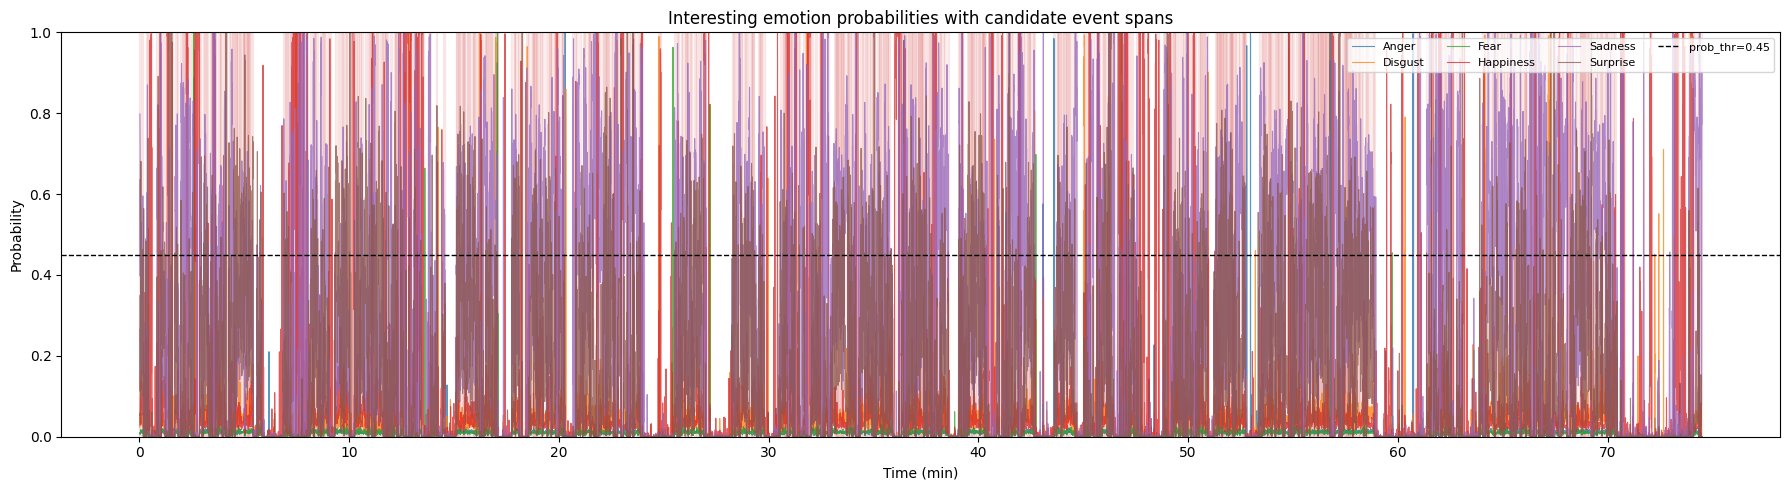

In [36]:
fig, ax = plt.subplots(figsize=(18, 5))

for class_idx, label in zip(interesting_idx, interesting_labels):
    ax.plot(frame_center_min, probs_np[:, class_idx], linewidth=0.8, alpha=0.75, label=label)

if len(events_df):
    for _, ev in events_df.iterrows():
        ax.axvspan(ev["start_min"], ev["end_min"], color="tab:red", alpha=0.08)

ax.axhline(PROB_THR, color="black", linestyle="--", linewidth=1, label=f"prob_thr={PROB_THR}")
ax.set_ylim(0, 1)
ax.set_xlabel("Time (min)")
ax.set_ylabel("Probability")
ax.set_title("Interesting emotion probabilities with candidate event spans")
ax.legend(loc="upper right", ncol=4, fontsize=8)
plt.tight_layout()
plt.show()


In [37]:
preview_events = []

for n, ev in events_df.head(20).iterrows():
    label = ev["label"].lower()
    preview_events.append({
        "event_id": f"emotion.categorical.v1.categorical.{n:06d}",
        "producer_id": "emotion.categorical.v1",
        "task": "emotion",
        "event_type": "categorical",
        "label": label,
        "start_sec": float(ev["start_sec"]),
        "end_sec": float(ev["end_sec"]),
        "duration_sec": float(ev["duration_sec"]),
        "source_track_ids": ("emotion.categorical.probabilities",),
        "score": float(ev["peak_prob"]),
        "score_name": "probability",
        "direction": None,
        "evidence": {
            "peak_time_sec": float(ev["peak_sec"]),
            "top_classes_at_peak": ev["top_classes_at_peak"],
            "interesting_mass_at_peak": float(ev["interesting_mass_at_peak"]),
            "margin_vs_background_at_peak": float(ev["peak_margin_vs_background"]),
        },
        "extra": {
            "frame_start": int(ev["frame_start"]),
            "frame_end": int(ev["frame_end"]),
            "prob_thr": PROB_THR,
            "margin_thr": MARGIN_THR,
            "min_duration_sec": MIN_DURATION_SEC,
            "merge_gap_sec": MERGE_GAP_SEC,
            "require_global_top1": REQUIRE_GLOBAL_TOP1,
        },
    })

display(pd.DataFrame(preview_events))


,event_id,producer_id,task,event_type,label,start_sec,end_sec,duration_sec,source_track_ids,score,score_name,direction,evidence,extra
0,emotion.categorical.v1.categorical.000000,emotion.categorical.v1,emotion,categorical,sadness,0.00,5.25,5.25,"(emotion.categorical.probabilities,)",0.798142,probability,None,"{'peak_time_sec': 1.5, 'top_classes_at_peak': ...","{'frame_start': 0, 'frame_end': 10, 'prob_thr'..."
1,emotion.categorical.v1.categorical.000001,emotion.categorical.v1,emotion,categorical,sadness,6.25,11.50,5.25,"(emotion.categorical.probabilities,)",0.595477,probability,None,"{'peak_time_sec': 9.75, 'top_classes_at_peak':...","{'frame_start': 25, 'frame_end': 35, 'prob_thr..."
2,emotion.categorical.v1.categorical.000002,emotion.categorical.v1,emotion,categorical,sadness,20.00,25.25,5.25,"(emotion.categorical.probabilities,)",0.869937,probability,None,"{'peak_time_sec': 23.0, 'top_classes_at_peak':...","{'frame_start': 80, 'frame_end': 90, 'prob_thr..."
3,emotion.categorical.v1.categorical.000003,emotion.categorical.v1,emotion,categorical,surprise,22.75,27.00,4.25,"(emotion.categorical.probabilities,)",0.738158,probability,None,"{'peak_time_sec': 25.0, 'top_classes_at_peak':...","{'frame_start': 91, 'frame_end': 97, 'prob_thr..."
4,emotion.categorical.v1.categorical.000004,emotion.categorical.v1,emotion,categorical,happiness,30.25,35.75,5.50,"(emotion.categorical.probabilities,)",0.996687,probability,None,"{'peak_time_sec': 33.75, 'top_classes_at_peak'...","{'frame_start': 121, 'frame_end': 132, 'prob_t..."
5,emotion.categorical.v1.categorical.000005,emotion.categorical.v1,emotion,categorical,sadness,48.75,54.75,6.00,"(emotion.categorical.probabilities,)",0.821189,probability,None,"{'peak_time_sec': 53.25, 'top_classes_at_peak'...","{'frame_start': 195, 'frame_end': 208, 'prob_t..."
6,emotion.categorical.v1.categorical.000006,emotion.categorical.v1,emotion,categorical,happiness,56.00,62.00,6.00,"(emotion.categorical.probabilities,)",0.999995,probability,None,"{'peak_time_sec': 60.0, 'top_classes_at_peak':...","{'frame_start': 224, 'frame_end': 237, 'prob_t..."
7,emotion.categorical.v1.categorical.000007,emotion.categorical.v1,emotion,categorical,sadness,58.75,67.00,8.25,"(emotion.categorical.probabilities,)",0.999995,probability,None,"{'peak_time_sec': 60.75, 'top_classes_at_peak'...","{'frame_start': 235, 'frame_end': 257, 'prob_t..."
8,emotion.categorical.v1.categorical.000008,emotion.categorical.v1,emotion,categorical,surprise,70.50,74.50,4.00,"(emotion.categorical.probabilities,)",0.481450,probability,None,"{'peak_time_sec': 72.0, 'top_classes_at_peak':...","{'frame_start': 282, 'frame_end': 287, 'prob_t..."
9,emotion.categorical.v1.categorical.000009,emotion.categorical.v1,emotion,categorical,happiness,77.75,84.50,6.75,"(emotion.categorical.probabilities,)",1.000000,probability,None,"{'peak_time_sec': 82.0, 'top_classes_at_peak':...","{'frame_start': 311, 'frame_end': 327, 'prob_t..."
